# 06 — Evaluation Expansion

**Week 8: California Property Close Price Prediction**

## Objective

Expand model evaluation beyond R² by calculating **MAPE** and **MdAPE**, then
analyze prediction accuracy across different property price bands.

This notebook compares:

- the best Week 6 model (**Linear Regression**), and
- the tuned Week 7 advanced model (**XGBoost**).

The main Week 8 deliverables are:

- overall R², MAPE, and MdAPE,
- price-band performance analysis,
- visualizations of percentage error, and
- `metrics_summary.csv`.


## 1. Imports and project paths


In [3]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


## 2. Load the Week 6 enriched test data

Week 8 keeps the same chronological test set used in Weeks 6 and 7 so the
evaluation remains directly comparable.


In [5]:
test_path = PROCESSED_DIR / "test_enriched_week6.csv"

if not test_path.exists():
    raise FileNotFoundError(
        "Missing processed/test_enriched_week6.csv. "
        "Run the Week 6 notebook first."
    )

test_df = pd.read_csv(
    test_path,
    low_memory=False
)

TARGET = "ClosePrice"

if TARGET not in test_df.columns:
    raise KeyError(f"{TARGET} is missing from the Week 6 test dataset.")

y_test = test_df[TARGET].to_numpy(dtype=float)

print("Testing rows:", len(test_df))
print("Minimum ClosePrice:", f"${np.nanmin(y_test):,.0f}")
print("Median ClosePrice:", f"${np.nanmedian(y_test):,.0f}")
print("Maximum ClosePrice:", f"${np.nanmax(y_test):,.0f}")


Testing rows: 12024
Minimum ClosePrice: $11,900
Median ClosePrice: $930,000
Maximum ClosePrice: $97,972,500


## 3. Define the enriched Week 6 feature set

The feature list matches the input structure used in the Week 7 XGBoost
notebook.


In [7]:
numeric_features = [
    c for c in [
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "OriginalListPrice",
        "Latitude",
        "Longitude",
        "GarageSpaces",
        "Stories",
        "PropertyAge",
        "BedBathRatio",
        "LivingAreaPerBedroom",
        "LotToLivingRatio",
    ]
    if c in test_df.columns
]

categorical_features = [
    c for c in [
        "CountyOrParish",
        "City",
        "PostalCode",
        "ArchitecturalStyle",
        "PropertyCondition",
        "DistrictName",
    ]
    if c in test_df.columns
]

feature_columns = numeric_features + categorical_features

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total raw input features:", len(feature_columns))


Numeric features: 14
Categorical features: 4
Total raw input features: 18


## 4. Load the saved Week 6 and Week 7 models


In [9]:
required_model_files = [
    MODELS_DIR / "week6_preprocessor.joblib",
    MODELS_DIR / "week6_linear_regression.joblib",
    MODELS_DIR / "week7_preprocessor.joblib",
    MODELS_DIR / "best_week7_xgboost.joblib",
]

missing = [str(path) for path in required_model_files if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Run Weeks 6 and 7 first. Missing files:\n"
        + "\n".join(missing)
    )

week6_preprocessor = joblib.load(
    MODELS_DIR / "week6_preprocessor.joblib"
)
week6_model = joblib.load(
    MODELS_DIR / "week6_linear_regression.joblib"
)

week7_preprocessor = joblib.load(
    MODELS_DIR / "week7_preprocessor.joblib"
)
week7_model = joblib.load(
    MODELS_DIR / "best_week7_xgboost.joblib"
)

print("Week 6 and Week 7 models loaded successfully.")


Week 6 and Week 7 models loaded successfully.


## 5. Generate predictions


In [11]:
X_test_week6 = week6_preprocessor.transform(
    test_df[feature_columns]
)

X_test_week7 = week7_preprocessor.transform(
    test_df[feature_columns]
)

week6_predictions = np.clip(
    week6_model.predict(X_test_week6),
    0,
    None
)

week7_predictions = np.clip(
    week7_model.predict(X_test_week7),
    0,
    None
)

prediction_df = pd.DataFrame({
    "ActualPrice": y_test,
    "Week6_LinearRegression": week6_predictions,
    "Week7_XGBoost": week7_predictions,
})

display(prediction_df.head())


,ActualPrice,Week6_LinearRegression,Week7_XGBoost
0,8712500.0,5.913908e+06,7583362.500
1,1100000.0,1.718255e+06,1076550.000
2,1625000.0,1.746677e+06,1331126.875
3,1560000.0,7.889235e+05,1536090.250
4,605000.0,1.092974e+06,712991.250


## 6. Evaluation metrics

Week 8 adds two percentage-based metrics:

- **MAPE (Mean Absolute Percentage Error):** the average absolute prediction
  error as a percentage of the actual price.
- **MdAPE (Median Absolute Percentage Error):** the median absolute percentage
  error. It is less sensitive than MAPE to a small number of unusually large
  errors.

Rows with an actual price of zero are excluded from percentage-error
calculations because percentage error would be undefined.


In [13]:
def absolute_percentage_errors(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    return (
        np.abs(y_true[valid] - y_pred[valid])
        / np.abs(y_true[valid])
        * 100
    )


def calculate_metrics(y_true, y_pred):
    ape = absolute_percentage_errors(y_true, y_pred)

    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(ape),
        "MdAPE": np.median(ape),
    }


## 7. Overall model comparison


In [15]:
model_predictions = {
    "Week 6 Linear Regression": week6_predictions,
    "Week 7 XGBoost": week7_predictions,
}

overall_rows = []

for model_name, pred in model_predictions.items():
    overall_rows.append({
        "Model": model_name,
        **calculate_metrics(y_test, pred),
    })

metrics_summary = (
    pd.DataFrame(overall_rows)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

display(
    metrics_summary.style.format({
        "R2": "{:.4f}",
        "MAE": "${:,.0f}",
        "RMSE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)


,Model,R2,MAE,RMSE,MAPE,MdAPE
0,Week 6 Linear Regression,0.3541,"$437,135","$1,348,581",46.68%,21.84%
1,Week 7 XGBoost,-1.7405,"$236,065","$2,777,938",27.31%,7.74%


## 8. Create property price bands

Price bands make it easier to see whether the model performs differently for
lower-priced, mid-range, and luxury properties.


In [17]:
price_bins = [
    0,
    500_000,
    750_000,
    1_000_000,
    2_000_000,
    np.inf,
]

price_labels = [
    "Under $500K",
    "$500K–$750K",
    "$750K–$1M",
    "$1M–$2M",
    "$2M+",
]

prediction_df["PriceBand"] = pd.cut(
    prediction_df["ActualPrice"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
    right=False,
)

display(
    prediction_df["PriceBand"]
    .value_counts(sort=False)
    .rename("Properties")
    .to_frame()
)


,Properties
PriceBand,
Under $500K,1644
$500K–$750K,2511
$750K–$1M,2370
$1M–$2M,3780
$2M+,1719


## 9. Evaluate each model by price band


In [19]:
band_rows = []

for band in price_labels:
    band_mask = prediction_df["PriceBand"].eq(band).to_numpy()

    if band_mask.sum() == 0:
        continue

    actual_band = y_test[band_mask]

    for model_name, pred in model_predictions.items():
        pred_band = pred[band_mask]
        metrics = calculate_metrics(actual_band, pred_band)

        band_rows.append({
            "PriceBand": band,
            "Model": model_name,
            "Properties": int(band_mask.sum()),
            **metrics,
        })

price_band_metrics = pd.DataFrame(band_rows)

display(
    price_band_metrics.style.format({
        "R2": "{:.4f}",
        "MAE": "${:,.0f}",
        "RMSE": "${:,.0f}",
        "MAPE": "{:.2f}%",
        "MdAPE": "{:.2f}%",
    })
)


,PriceBand,Model,Properties,R2,MAE,RMSE,MAPE,MdAPE
0,Under $500K,Week 6 Linear Regression,1644,-58.2873,"$277,556","$682,004",109.78%,41.86%
1,Under $500K,Week 7 XGBoost,1644,-5.0006,"$113,661","$216,971",64.79%,19.49%
2,$500K–$750K,Week 6 Linear Regression,2511,-77.6611,"$309,803","$631,305",49.71%,30.07%
3,$500K–$750K,Week 7 XGBoost,2511,-4365.6373,"$229,299","$4,703,624",34.54%,7.56%
4,$750K–$1M,Week 6 Linear Regression,2370,-170.0652,"$399,668","$925,311",46.47%,20.44%
5,$750K–$1M,Week 7 XGBoost,2370,-1839.2587,"$291,976","$3,034,914",34.72%,12.09%
6,$1M–$2M,Week 6 Linear Regression,3780,-5.9398,"$378,333","$705,311",28.02%,16.18%
7,$1M–$2M,Week 7 XGBoost,3780,-2.6986,"$126,034","$514,904",9.26%,5.23%
8,$2M+,Week 6 Linear Regression,1719,0.2389,"$956,708","$3,069,173",23.25%,17.83%
9,$2M+,Week 7 XGBoost,1719,0.3266,"$527,882","$2,886,848",10.37%,7.22%


## 10. Identify the strongest and weakest price bands

For percentage accuracy, a **lower MdAPE is better**.


In [21]:
for model_name in model_predictions:
    model_bands = (
        price_band_metrics[
            price_band_metrics["Model"].eq(model_name)
        ]
        .sort_values("MdAPE")
        .reset_index(drop=True)
    )

    best_band = model_bands.iloc[0]
    worst_band = model_bands.iloc[-1]

    print(f"\n{model_name}")
    print(
        "Best price band by MdAPE:",
        best_band["PriceBand"],
        f"({best_band['MdAPE']:.2f}%)"
    )
    print(
        "Weakest price band by MdAPE:",
        worst_band["PriceBand"],
        f"({worst_band['MdAPE']:.2f}%)"
    )



Week 6 Linear Regression
Best price band by MdAPE: $1M–$2M (16.18%)
Weakest price band by MdAPE: Under $500K (41.86%)

Week 7 XGBoost
Best price band by MdAPE: $1M–$2M (5.23%)
Weakest price band by MdAPE: Under $500K (19.49%)


## 11. MAPE by price band


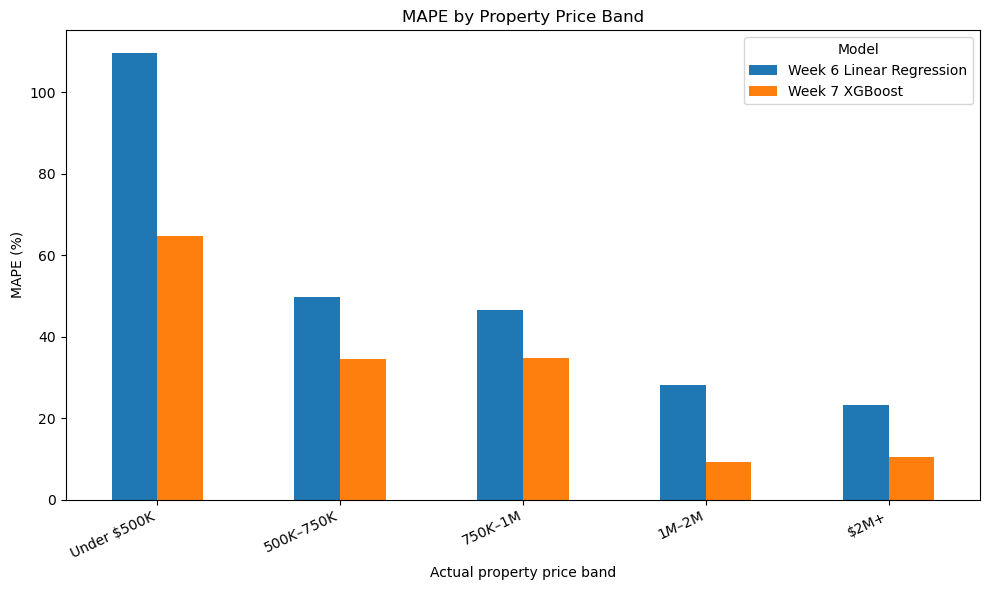

In [23]:
mape_pivot = price_band_metrics.pivot(
    index="PriceBand",
    columns="Model",
    values="MAPE"
).reindex(price_labels)

ax = mape_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("MAPE (%)")
plt.xlabel("Actual property price band")
plt.title("MAPE by Property Price Band")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 12. MdAPE by price band


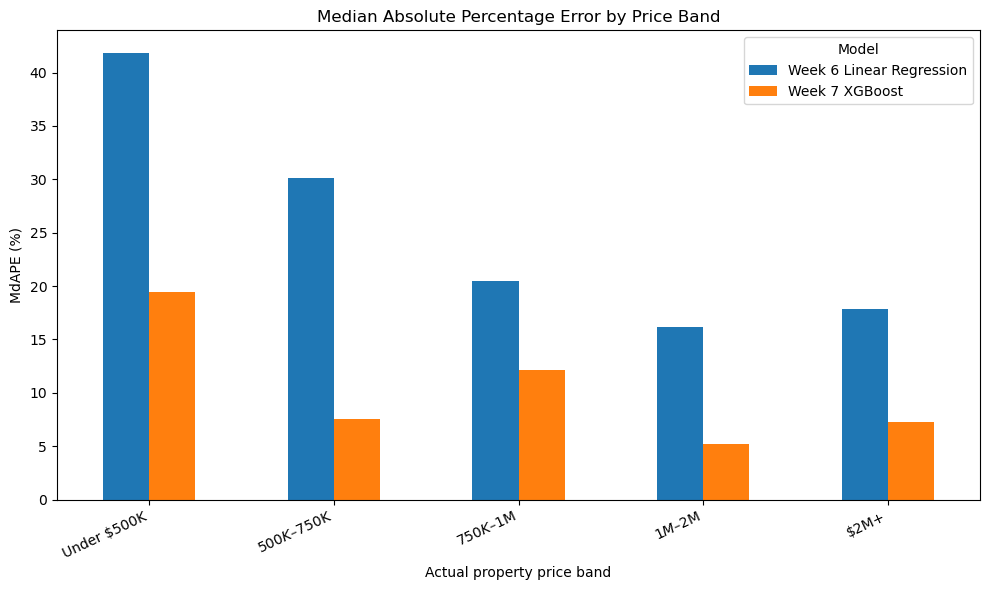

In [25]:
mdape_pivot = price_band_metrics.pivot(
    index="PriceBand",
    columns="Model",
    values="MdAPE"
).reindex(price_labels)

ax = mdape_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("MdAPE (%)")
plt.xlabel("Actual property price band")
plt.title("Median Absolute Percentage Error by Price Band")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 13. Distribution of absolute percentage error

The 99th percentile limit keeps a few extreme errors from compressing the
majority of observations in the chart.


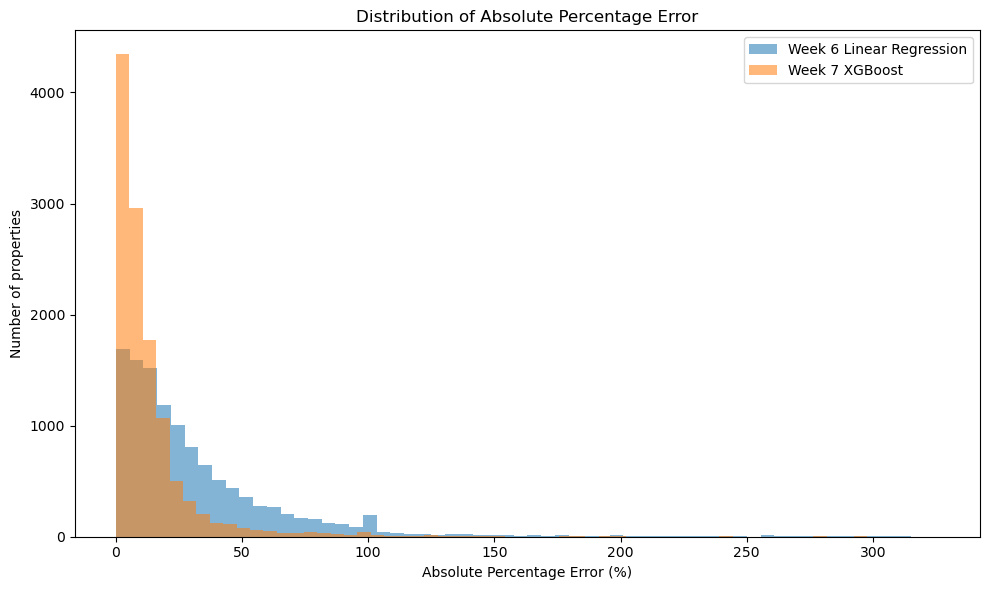

In [27]:
week6_ape = absolute_percentage_errors(
    y_test,
    week6_predictions
)
week7_ape = absolute_percentage_errors(
    y_test,
    week7_predictions
)

plot_limit = np.quantile(
    np.concatenate([week6_ape, week7_ape]),
    0.99
)

plt.figure(figsize=(10, 6))

plt.hist(
    week6_ape[week6_ape <= plot_limit],
    bins=60,
    alpha=0.55,
    label="Week 6 Linear Regression"
)

plt.hist(
    week7_ape[week7_ape <= plot_limit],
    bins=60,
    alpha=0.55,
    label="Week 7 XGBoost"
)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Number of properties")
plt.title("Distribution of Absolute Percentage Error")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Save Week 8 deliverables


In [29]:
metrics_summary.to_csv(
    RESULTS_DIR / "metrics_summary.csv",
    index=False
)

price_band_metrics.to_csv(
    RESULTS_DIR / "week8_price_band_metrics.csv",
    index=False
)

prediction_df.to_csv(
    RESULTS_DIR / "week8_predictions.csv",
    index=False
)

print("Saved:")
print("-", RESULTS_DIR / "metrics_summary.csv")
print("-", RESULTS_DIR / "week8_price_band_metrics.csv")
print("-", RESULTS_DIR / "week8_predictions.csv")


Saved:
- results\metrics_summary.csv
- results\week8_price_band_metrics.csv
- results\week8_predictions.csv


## 14.5. Diagnose extreme XGBoost errors

Because XGBoost has good percentage-error metrics but poor R²/RMSE, inspect the largest absolute errors and how much they contribute to total squared error.


In [ ]:
diagnostic_df = prediction_df.copy()

diagnostic_df["XGB_AbsoluteError"] = (
    diagnostic_df["Week7_XGBoost"] - diagnostic_df["ActualPrice"]
).abs()

diagnostic_df["XGB_APE"] = (
    diagnostic_df["XGB_AbsoluteError"]
    / diagnostic_df["ActualPrice"].abs()
    * 100
)

diagnostic_df["XGB_SquaredError"] = (
    diagnostic_df["Week7_XGBoost"] - diagnostic_df["ActualPrice"]
) ** 2

top_xgb_outliers = (
    diagnostic_df
    .sort_values("XGB_AbsoluteError", ascending=False)
    .head(15)
)

display(
    top_xgb_outliers[
        [
            "ActualPrice",
            "Week7_XGBoost",
            "XGB_AbsoluteError",
            "XGB_APE",
        ]
    ].style.format({
        "ActualPrice": "${:,.0f}",
        "Week7_XGBoost": "${:,.0f}",
        "XGB_AbsoluteError": "${:,.0f}",
        "XGB_APE": "{:.2f}%",
    })
)

total_sse = diagnostic_df["XGB_SquaredError"].sum()

for n in [1, 5, 10, 20, 50]:
    share = (
        diagnostic_df.nlargest(n, "XGB_SquaredError")["XGB_SquaredError"].sum()
        / total_sse
        * 100
    )
    print(f"Top {n} observations account for {share:.2f}% of XGBoost total squared error.")


## 15. Summary

### Overall performance

The Week 8 evaluation shows that the two models behave very differently depending on the metric used.

- **Best model by R²:** Week 6 Linear Regression (**0.3541**)
- **Best model by MAPE:** Week 7 XGBoost (**27.31%**)
- **Best model by MdAPE:** Week 7 XGBoost (**7.74%**)

Week 7 XGBoost has a much lower MAE, MAPE, and MdAPE than Week 6 Linear Regression. Its MdAPE of **7.74%** indicates that the typical prediction is relatively close to the actual sale price. However, XGBoost has a negative R² (**-1.7405**) and a high RMSE (**about $2.78 million**), showing that a small number of very large prediction errors strongly affect squared-error metrics.

### Price-band findings

For XGBoost, the **$1M–$2M** band performs best by MdAPE at **5.23%**. The **Under $500K** band performs worst by MdAPE at **19.49%**.

The price-band results show that percentage accuracy is not uniform across the housing market. XGBoost performs especially well for many mid-to-high-priced properties, while lower-priced properties have larger typical percentage errors.

### Outlier finding

The error diagnostics show that the poor XGBoost R² is driven disproportionately by a small number of extreme prediction errors. This explains why XGBoost can have strong MAE/MAPE/MdAPE results while simultaneously producing weak RMSE and R².

### Conclusion

Week 8 expanded evaluation beyond R² by adding MAPE and MdAPE and examining performance by actual property price band. The results demonstrate why multiple metrics are necessary: **XGBoost provides substantially better typical percentage accuracy than Linear Regression, but extreme outliers make its squared-error performance much worse.**

Before deployment, the next modeling improvement should investigate these extreme XGBoost errors and consider methods such as target transformation, outlier treatment, or additional feature/model tuning. The current Week 8 results are saved in `results/metrics_summary.csv`, `results/week8_price_band_metrics.csv`, and `results/week8_predictions.csv`.
